#Smita Dhungel
#2418272

Exercise 1 – Image Processing with RGB

1.Install and Import Libraries

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

2.Read and Display Image

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving lena_gray.gif to lena_gray.gif


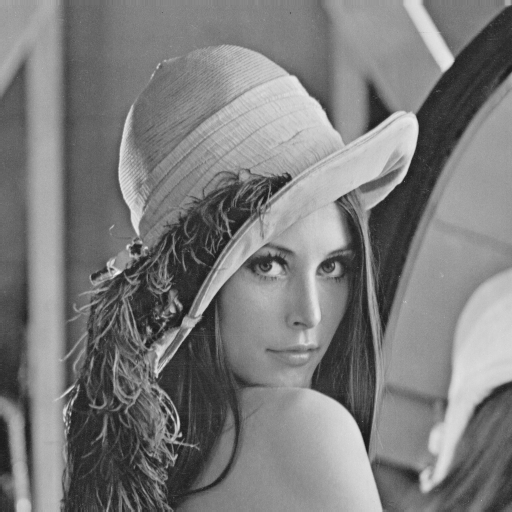

In [ ]:
from PIL import Image
from IPython.display import display

image = Image.open("lena_gray.gif")
display(image)

3.Display Top Left 100x100 Pixels

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

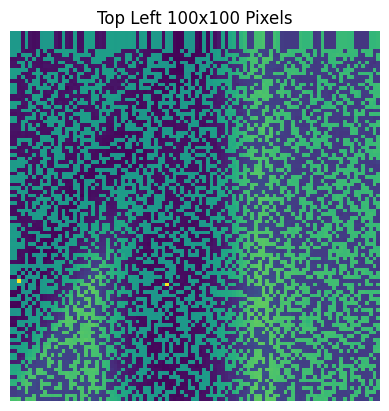

In [ ]:
img_np = np.array(image)

top_left = img_np[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")

4.Show RGB Channels

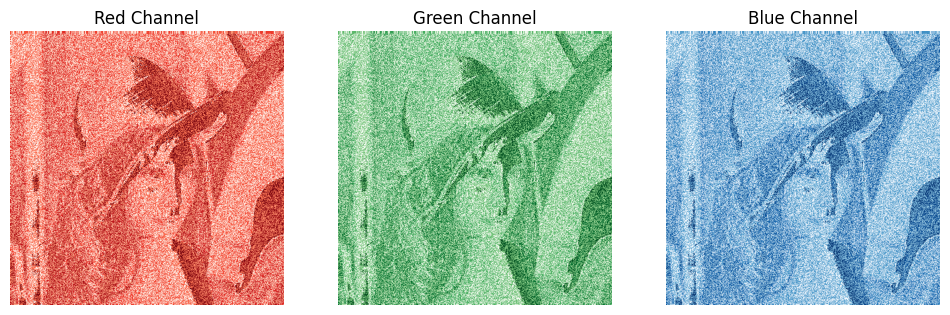

In [ ]:
img_np_rgb = np.stack([img_np, img_np, img_np], axis=-1)
R = img_np_rgb[:,:,0]
G = img_np_rgb[:,:,1]
B = img_np_rgb[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

5.Modify Top 100x100 Pixels to 210

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

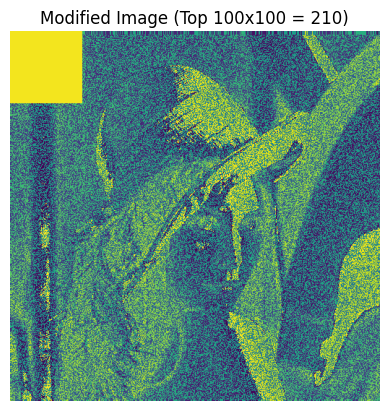

In [ ]:
modified_img = img_np.copy()

modified_img[0:100,0:100] = 210

plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")

Exercise 2 – Grayscale Image Processing

1.Load Grayscale Image

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

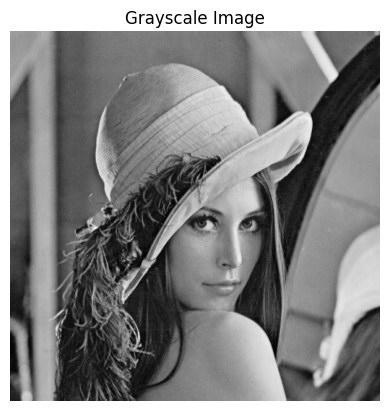

In [ ]:
gray_img = Image.open(list(uploaded.keys())[0]).convert('L')

plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

2.Extract Middle 150 Pixels

(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

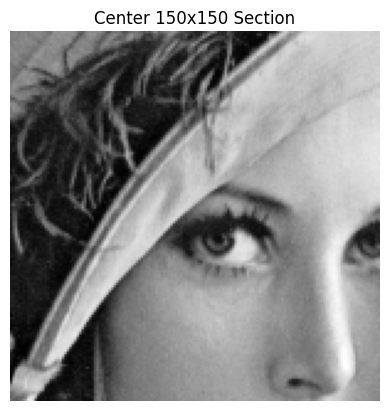

In [ ]:
gray_np = np.array(gray_img)

h, w = gray_np.shape

center = gray_np[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center, cmap='gray')
plt.title("Center 150x150 Section")
plt.axis("off")

2.Apply Threshold

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

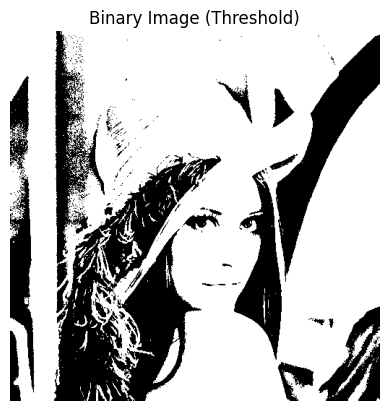

In [ ]:
binary = gray_np.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap='gray')
plt.title("Binary Image (Threshold)")
plt.axis("off")

4.Rotate Image 90° Clockwise

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

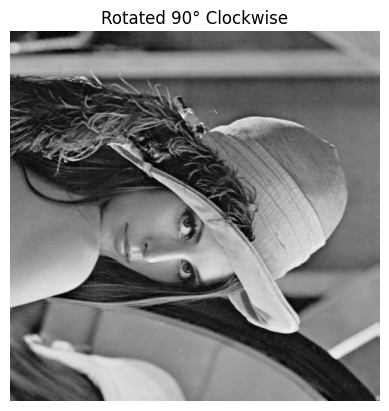

In [ ]:
rotated = gray_img.rotate(-90, expand=True)

plt.imshow(rotated, cmap='gray')
plt.title("Rotated 90° Clockwise")
plt.axis("off")

5.Convert Grayscale to RGB

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

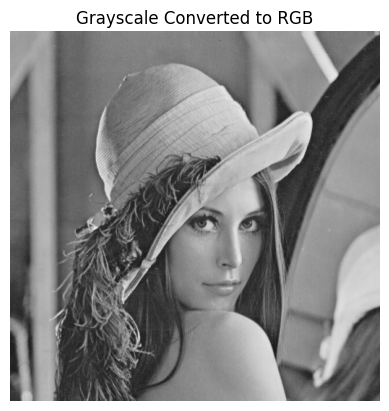

In [ ]:
rgb_img = np.stack((gray_np,)*3, axis=-1)

plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")

Exercise 3 – PCA Image Compression (From Scratch)

1.Load and Prepare Image

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

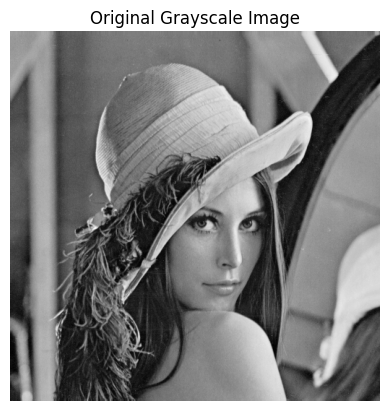

In [ ]:
img = Image.open(list(uploaded.keys())[0]).convert('L')
img = np.array(img)

plt.imshow(img, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

2.Standardize Data

In [ ]:
mean = np.mean(img, axis=0)
centered = img - mean

3.Covariance Matrix

In [ ]:
cov_matrix = np.cov(centered, rowvar=False)

4.Eigenvalues and Eigenvectors

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

5.Sort Eigenvalues

In [ ]:
sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:,sorted_index]

6.Cumulative Explained Variance Plot

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


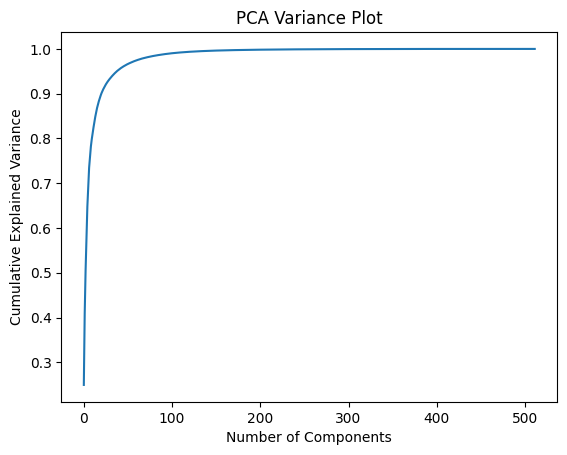

In [ ]:
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Plot")
plt.show()

7.Reconstruction with Different Principal Components

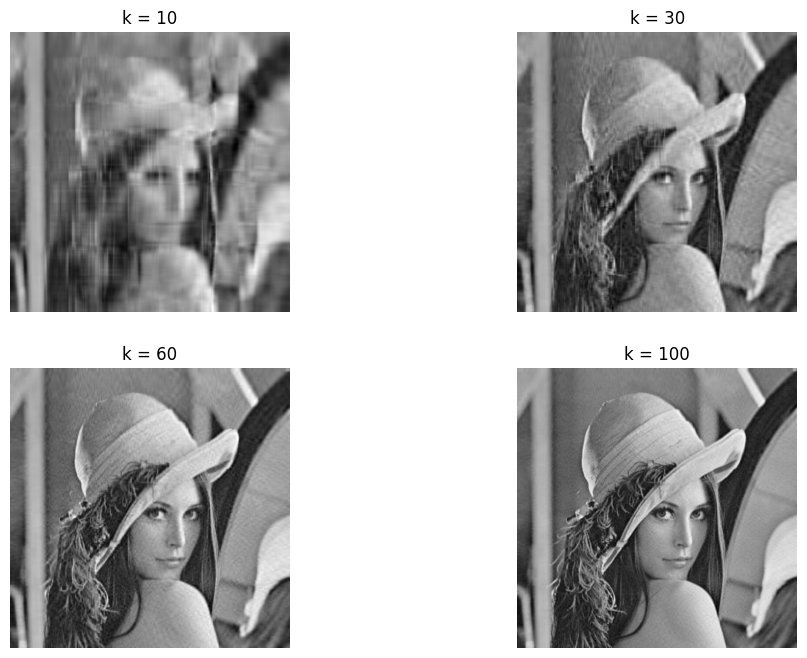

In [ ]:
k_values = [10, 30, 60, 100]

plt.figure(figsize=(12,8))

for i,k in enumerate(k_values):

    eigenvector_subset = sorted_eigenvectors[:,0:k]

    compressed = np.dot(centered, eigenvector_subset)

    reconstructed = (np.dot(compressed, eigenvector_subset.T) + mean).real

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis("off")

plt.show()